# Biodegradation percentage Preprocessing

**Author:** Lab of Farm Structures
**Date:** 2026-03

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import math
import re

## Import Data

In [2]:
database = 'PHBV_Biodegradation_Curated_Raw_Dataset'

## Create DataFrames for data points and properties

In [3]:
# material properties DataFrame
df_material = pd.read_excel(f'{database}.xlsx', sheet_name='Materials_features')

# Environmental properties DataFrame
df_environment = pd.read_excel(f'{database}.xlsx', sheet_name='Environmental_features')

# biodegradation percentage DataFrame
df_biodeg = pd.read_excel(f'{database}.xlsx', sheet_name='Biodegradation_features')

# Time points degradation DataFrame
df_time = pd.read_excel(f'{database}.xlsx', sheet_name='Time_point_features')

## Drop duplicates and remove multiple study+instance case (keep first)

In [4]:
print("Enviromental Properties, rows before:", df_environment.shape[0])
df_environment = df_environment.drop_duplicates()
print("Enviromental Properties, rows after:", df_environment.shape[0])

Enviromental Properties, rows before: 98
Enviromental Properties, rows after: 98


In [5]:
print("material Properties, rows before:", df_material.shape[0])
df_material = df_material.drop_duplicates(subset=['Study_id', 'Instance'])
print("material Properties, rows after:", df_material.shape[0])

material Properties, rows before: 98
material Properties, rows after: 93


## Merge material & enviromental properties

In [6]:
df_merged_prop = pd.merge(df_material, df_environment,  on=['Study_id', 'Instance'], how='left')
df_merged_prop.tail()

,Study_id,Instance,Sample_name,{Sample ratio wt/wt%},Monomer_A,Monomer_B,Adjusted_HB_ratio_formulation (mol%),Adjusted_HV_ratio_formulation (mol%),Additives,Additive1_name,...,Compost_pH,Compost_T (°C),TOCA %,TNA %,TDS %,C/N,VS %,{**PHA_degrading_microbes},Degradation_Environment,ASTM/ISO
88,23,4,PHBV- pF,85/15,PHB,PHV,82.45,2.55,Yes,Pulp-rich (PF),...,NaN,NaN,NaN,NaN,NaN,550.0,NaN,"bacteria, fungi, actinomycetes",soil,ASTMD5988-96
89,24,1,PHBV,100/0,PHB,PHV,98.50,1.50,No,NaN,...,NaN,NaN,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,UNE-ISO 23977-1
90,24,2,PHBV_c,95/5,PHB,PHV,93.58,1.43,Yes,Catechin,...,NaN,NaN,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,UNE-ISO 23977-1
91,24,3,PHBV_f,95/5,PHB,PHV,93.58,1.43,Yes,Ferulic Acid,...,NaN,NaN,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,UNE-ISO 23977-1
92,24,4,PHBV_v,95/5,PHB,PHV,93.58,1.43,Yes,Vanillin,...,NaN,NaN,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,UNE-ISO 23977-1


## Melt t values

In [7]:
id_cols = ["Study_id", "Instance", "Sample_name"]

value_cols = [c for c in df_time.columns if c not in id_cols]

df_time[value_cols] = df_time[value_cols].apply(
    pd.to_numeric, errors="coerce"
)
t_long = (
    df_time
    .set_index(id_cols)[value_cols]
    .stack()
    .reset_index(level=-1, drop=True)
    .reset_index(name="t_value")
)
t_long = t_long.dropna(subset=["t_value"])
t_long.tail()

,Study_id,Instance,Sample_name,t_value
1409,24,4,PHBV_v,132.64536
1410,24,4,PHBV_v,141.01745
1411,24,4,PHBV_v,145.46513
1412,24,4,PHBV_v,152.65990
1413,24,4,PHBV_v,157.36920


## Melt y values

In [8]:
id_cols = ["Study_id", "Instance", "Sample_name"]

value_cols = [c for c in df_biodeg.columns if c not in id_cols]

df_biodeg[value_cols] = df_biodeg[value_cols].apply(
    pd.to_numeric, errors="coerce"
)
y_long = (
    df_biodeg
    .set_index(id_cols)[value_cols]
    .stack()
    .reset_index(level=-1, drop=True)
    .reset_index(name="y_value")
)
y_long = y_long.dropna(subset=["y_value"])
y_long.tail()

,Study_id,Instance,Sample_name,y_value
1409,24,4,PHBV_v,96.51303
1410,24,4,PHBV_v,99.31864
1411,24,4,PHBV_v,101.56313
1412,24,4,PHBV_v,103.93540
1413,24,4,PHBV_v,104.94541


## Merge t and y values

In [9]:
t_long = t_long.reset_index(drop=True)
y_long = y_long.reset_index(drop=True)
ty_df = pd.concat(
    [
        t_long[["Study_id", "Instance", "Sample_name", "t_value"]],
        y_long[["y_value"]]
    ],
    axis=1
)
ty_df.tail()

,Study_id,Instance,Sample_name,t_value,y_value
1409,24,4,PHBV_v,132.64536,96.51303
1410,24,4,PHBV_v,141.01745,99.31864
1411,24,4,PHBV_v,145.46513,101.56313
1412,24,4,PHBV_v,152.65990,103.93540
1413,24,4,PHBV_v,157.36920,104.94541


## Merge properties with t,y values

In [10]:
df_merged_fnl = df_merged_prop.merge(
    ty_df[['Study_id', 'Instance', 't_value', 'y_value']],
    on=['Study_id', 'Instance'],
    how='left'
)
df_merged_fnl = df_merged_fnl.dropna(subset=['t_value', 'y_value'])
df_merged_fnl.tail()

,Study_id,Instance,Sample_name,{Sample ratio wt/wt%},Monomer_A,Monomer_B,Adjusted_HB_ratio_formulation (mol%),Adjusted_HV_ratio_formulation (mol%),Additives,Additive1_name,...,TOCA %,TNA %,TDS %,C/N,VS %,{**PHA_degrading_microbes},Degradation_Environment,ASTM/ISO,t_value,y_value
1410,24,4,PHBV_v,95/5,PHB,PHV,93.58,1.43,Yes,Vanillin,...,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,UNE-ISO 23977-1,132.64536,96.51303
1411,24,4,PHBV_v,95/5,PHB,PHV,93.58,1.43,Yes,Vanillin,...,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,UNE-ISO 23977-1,141.01745,99.31864
1412,24,4,PHBV_v,95/5,PHB,PHV,93.58,1.43,Yes,Vanillin,...,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,UNE-ISO 23977-1,145.46513,101.56313
1413,24,4,PHBV_v,95/5,PHB,PHV,93.58,1.43,Yes,Vanillin,...,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,UNE-ISO 23977-1,152.65990,103.93540
1414,24,4,PHBV_v,95/5,PHB,PHV,93.58,1.43,Yes,Vanillin,...,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,UNE-ISO 23977-1,157.36920,104.94541


## Rename t and y values

In [11]:
df_merged_fnl = df_merged_fnl.rename(columns={
    't_value': 'biodegradation_time_(days)',
    'y_value': 'biodegradation_percentage'
})

df_merged_fnl.columns

Index(['Study_id', 'Instance', ' Sample_name', '{Sample ratio wt/wt%}',
       'Monomer_A', 'Monomer_B', 'Adjusted_HB_ratio_formulation (mol%)',
       'Adjusted_HV_ratio_formulation (mol%) ', 'Additives', 'Additive1_name',
       'Additive_type_1', 'Additive1_percentage (wt%)', 'Additive2_name',
       'Additive_type_2', 'Additive2_percentage (wt%)', 'Additive3_name',
       'Additive_type_3', 'Additive3_percentage (wt%)',
       'PHBV_weight_percentage_final_formulation (wt%)', 'Mw (kDa)', 'Density',
       'Density_units', 'Sample_shape/Morphology', 'Size_diameter',
       'Size_length', 'Size_width', 'Size_thickness', 'Size_units',
       'permeability_water_vapor  (x10^13 mol * m/(m^2*s*Pa))',
       'Water_absorption_capacity %', 'Film_solubility %',
       'PHBV _crystallinity (%)',
       'Static_water_contact _angle, (WCA) for hydrophilicity (deg) ',
       'Sample_name', 'Parameter_evaluated', 'Biodegradation_condition',
       '*Degradation_mechanism', 'T_biodeg', 'T_biodeg_

## Drop duplicates

In [12]:
df_merged_fnl = df_merged_fnl.drop_duplicates()

## Replace N/A values with nan

In [13]:
df_merged_fnl = df_merged_fnl.replace(
    ["N/A", "n/a", "NA", "na"],
    np.nan
)

In [14]:
df_merged_fnl = df_merged_fnl.drop(columns=['Sample_name'])
df_merged_fnl.columns

Index(['Study_id', 'Instance', ' Sample_name', '{Sample ratio wt/wt%}',
       'Monomer_A', 'Monomer_B', 'Adjusted_HB_ratio_formulation (mol%)',
       'Adjusted_HV_ratio_formulation (mol%) ', 'Additives', 'Additive1_name',
       'Additive_type_1', 'Additive1_percentage (wt%)', 'Additive2_name',
       'Additive_type_2', 'Additive2_percentage (wt%)', 'Additive3_name',
       'Additive_type_3', 'Additive3_percentage (wt%)',
       'PHBV_weight_percentage_final_formulation (wt%)', 'Mw (kDa)', 'Density',
       'Density_units', 'Sample_shape/Morphology', 'Size_diameter',
       'Size_length', 'Size_width', 'Size_thickness', 'Size_units',
       'permeability_water_vapor  (x10^13 mol * m/(m^2*s*Pa))',
       'Water_absorption_capacity %', 'Film_solubility %',
       'PHBV _crystallinity (%)',
       'Static_water_contact _angle, (WCA) for hydrophilicity (deg) ',
       'Parameter_evaluated', 'Biodegradation_condition',
       '*Degradation_mechanism', 'T_biodeg', 'T_biodeg_units',
       

## Fix typos, excl. special characters

In [15]:
def clean_column_name(col):
    col = col.strip().lower()
    col = re.sub(r'[%()]', '', col)        # remove % ( )
    col = re.sub(r'[\/]', '_', col)        # / → _
    col = re.sub(r'\s+', '_', col)         # spaces → _
    col = re.sub(r'[^a-z0-9_]', '', col)   # remove remaining special chars
    col = re.sub(r'_+', '_', col)           # collapse multiple _
    col = col.strip('_')
    return col

def clean_cell_value(val):
    if isinstance(val, str):
        val = val.strip().lower()
        val = re.sub(r'[%()]', '', val)       # remove % ( )
        val = re.sub(r'[\/]', '_', val)       # / → _
        val = re.sub(r'\s+', '_', val)        # spaces → _
        val = re.sub(r'[^a-z0-9_]', '', val)  # remove remaining special chars
        val = re.sub(r'_+', '_', val)         # collapse multiple _
        val = val.strip('_')
    return val

In [16]:
df_merged_fnl.columns = [clean_column_name(c) for c in df_merged_fnl.columns]
df_merged_fnl.head()

,study_id,instance,sample_name,sample_ratio_wt_wt,monomer_a,monomer_b,adjusted_hb_ratio_formulation_mol,adjusted_hv_ratio_formulation_mol,additives,additive1_name,...,toca,tna,tds,c_n,vs,pha_degrading_microbes,degradation_environment,astm_iso,biodegradation_time_days,biodegradation_percentage
0,1,1,PHBV (with plasticizer),90/10,PHB,PHV,79.2,10.8,Yes,Citric Acid,...,10.6,0.9,55.0,11.8,53.0,thermophilic bacteria and fungi,industrial compost,ASTM D5338-15,5.029011,3.639010
1,1,1,PHBV (with plasticizer),90/10,PHB,PHV,79.2,10.8,Yes,Citric Acid,...,10.6,0.9,55.0,11.8,53.0,thermophilic bacteria and fungi,industrial compost,ASTM D5338-15,8.704062,4.967985
2,1,1,PHBV (with plasticizer),90/10,PHB,PHV,79.2,10.8,Yes,Citric Acid,...,10.6,0.9,55.0,11.8,53.0,thermophilic bacteria and fungi,industrial compost,ASTM D5338-15,12.959376,5.531300
3,1,1,PHBV (with plasticizer),90/10,PHB,PHV,79.2,10.8,Yes,Citric Acid,...,10.6,0.9,55.0,11.8,53.0,thermophilic bacteria and fungi,industrial compost,ASTM D5338-15,18.568664,6.221254
4,1,1,PHBV (with plasticizer),90/10,PHB,PHV,79.2,10.8,Yes,Citric Acid,...,10.6,0.9,55.0,11.8,53.0,thermophilic bacteria and fungi,industrial compost,ASTM D5338-15,22.437136,6.385741


In [17]:
df_clean = df_merged_fnl.copy()

# apply only to object (string) columns
obj_cols = df_clean.select_dtypes(include='object').columns

df_clean[obj_cols] = df_clean[obj_cols].apply( lambda col: col.map(clean_cell_value) )

## Process additive %

In [18]:
df_clean['additive_type_1'] = df_clean['additive_type_1'].replace(' filler', 'filler')

df_clean.loc[df_clean['additive1_percentage_wt'].isna(), 'additive1_percentage_wt'] = 0
df_clean.loc[df_clean['additive2_percentage_wt'].isna(), 'additive2_percentage_wt'] = 0
df_clean.loc[df_clean['additive3_percentage_wt'].isna(), 'additive3_percentage_wt'] = 0

In [19]:
df_clean['additive1_percentage_wt'] = pd.to_numeric(df_clean['additive1_percentage_wt'],errors='coerce')
df_clean['additive2_percentage_wt'] = pd.to_numeric(df_clean['additive2_percentage_wt'],errors='coerce')
df_clean['additive3_percentage_wt'] = pd.to_numeric(df_clean['additive3_percentage_wt'],errors='coerce')

df_clean['additive1'] = df_clean['additive1_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')
df_clean['additive2'] = df_clean['additive2_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')
df_clean['additive3'] = df_clean['additive3_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')

df_clean.loc[df_clean['additive1'] == 'no', 'additive_type_1'] = 'not_applicable'
df_clean.loc[df_clean['additive2'] == 'no', 'additive_type_2'] = 'not_applicable'
df_clean.loc[df_clean['additive3'] == 'no', 'additive_type_3'] = 'not_applicable'

## Drop features with more than 80% missing values

In [20]:
df_clean = df_clean.loc[:, df_clean.isna().mean() < 0.20]
df_clean.columns

Index(['study_id', 'instance', 'sample_name', 'sample_ratio_wt_wt',
       'monomer_a', 'monomer_b', 'adjusted_hb_ratio_formulation_mol',
       'adjusted_hv_ratio_formulation_mol', 'additives', 'additive1_name',
       'additive_type_1', 'additive1_percentage_wt', 'additive_type_2',
       'additive2_percentage_wt', 'additive_type_3', 'additive3_percentage_wt',
       'phbv_weight_percentage_final_formulation_wt',
       'sample_shape_morphology', 'parameter_evaluated',
       'biodegradation_condition', 'degradation_mechanism', 't_biodeg',
       't_biodeg_units', 'pha_degrading_microbes', 'degradation_environment',
       'astm_iso', 'biodegradation_time_days', 'biodegradation_percentage',
       'additive1', 'additive2', 'additive3'],
      dtype='object')

## Feature engineering

In [21]:
df_clean['degradation_mechanism'].value_counts()

degradation_mechanism
enzymemediated_microbial_biodegradation      652
hydrolysisassisted_microbial_assimilation    384
surface_erosiondriven_biodegradation         301
microbial_biodegradation                      77
Name: count, dtype: int64

In [22]:
mechanism_mapping = {
    "enzymemediated_microbial_biodegradation": "enzyme_mediated_microbial_biodegradation",
    "hydrolysisassisted_microbial_assimilation": "hydrolysis_assisted_microbial_assimilation",
    "surface_erosiondriven_biodegradation": "surface_erosion_driven_biodegradation",
    "microbial_biodegradation": "microbial_biodegradation"
}

In [23]:
df_clean["degradation_mechanism"] = (
    df_clean["degradation_mechanism"]
    .str.strip()  # remove leading/trailing whitespace
    .map(mechanism_mapping)
    .fillna("uncategorized")
)
df_clean["degradation_mechanism"].value_counts()

degradation_mechanism
enzyme_mediated_microbial_biodegradation      652
hydrolysis_assisted_microbial_assimilation    384
surface_erosion_driven_biodegradation         301
microbial_biodegradation                       77
Name: count, dtype: int64

In [24]:
df_clean['sample_shape_morphology'].value_counts()

sample_shape_morphology
films                                                     532
circular_blend_films                                      192
sheets                                                    138
rectangular_strips_flat_sheets                            130
continuous_phbv_matrix_with_dispersed_filler_particles    109
filaments_pellets                                          98
film                                                       92
square_films                                               81
particle                                                   28
matrix                                                     14
Name: count, dtype: int64

In [25]:
morphology_mapping = {
    "films": "films",
    "film": "films",
    "circular_blend_films": "films",
    "square_films": "films",
    "sheets": "sheets",
    "rectangular_strips_flat_sheets": "sheets",
    "particle": "particles",
    "continuous_phbv_matrix_with_dispersed_filler_particles": "matrix_composites",
    "matrix": "matrix_composites",
    "filaments_pellets": "pellets"
}

In [26]:
df_clean["sample_shape_morphology"] = (
    df_clean["sample_shape_morphology"]
    .str.strip()  # remove leading/trailing whitespace
    .map(morphology_mapping)
    .fillna("uncategorized")
)
df_clean["sample_shape_morphology"].value_counts()

sample_shape_morphology
films                897
sheets               268
matrix_composites    123
pellets               98
particles             28
Name: count, dtype: int64

In [27]:
df_clean['pha_degrading_microbes'].value_counts()

pha_degrading_microbes
bacteria_and_fungi                                                                                                                                                                         359
the_phas_degraders_were_identified_from_genus_cupriavidus_acidovorax_variovora_streptomyces_and_ideonella_and_two_starch_degraders_were_identified_from_genus_moraxella_and_alcaligenes    192
thermophilic_bacteria_fungi                                                                                                                                                                182
fungi_yeasts_and_bacteria                                                                                                                                                                  119
marine_bacteria_and_fungi                                                                                                                                                                  109
bacteria_and_possibly_

In [28]:
pha_microbe_mapping = {
    "bacteria_and_fungi": "bacteria_dominated",
    "bacteria": "bacteria_dominated",
    "the_phas_degraders_were_identified_from_genus_cupriavidus_acidovorax_variovora_streptomyces_and_ideonella_and_two_starch_degraders_were_identified_from_genus_moraxella_and_alcaligenes": "bacteria_dominated",
    "marine_bacteria_and_fungi": "bacteria_dominated",
    "thermophilic_bacteria_fungi": "bacteria_dominated",
    "thermophilic_bacteria_and_fungi": "bacteria_dominated",
    "fungi": "fungi_dominated",
    "fungi_yeasts_and_bacteria": "bacteria_fungi_mixed",
    "bacteria_fungi_actinomycetes": "bacteria_fungi_mixed",
    "mixed_microbial_community": "diverse_environmental",
    "bacteria_and_possibly_fungi_or_algae": "diverse_environmental",
}

In [29]:
df_clean["pha_degrading_microbes"] = (
    df_clean["pha_degrading_microbes"]
    .str.strip()  # remove leading/trailing whitespace
    .map(pha_microbe_mapping)
    .fillna("uncategorized")
)
df_clean["pha_degrading_microbes"].value_counts()

pha_degrading_microbes
bacteria_dominated       953
bacteria_fungi_mixed     200
diverse_environmental    179
fungi_dominated           42
uncategorized             40
Name: count, dtype: int64

In [30]:
df_clean['degradation_environment'].value_counts()

degradation_environment
soil                     389
thermophilic_compost     353
marine                   309
compost                  156
freshwater                96
liquid_mineral_medium     59
industrial_compost        52
Name: count, dtype: int64

In [31]:
origin_mapping = {
    "soil":"soil",
    "marine": "marine_aquatic",
    "freshwater": "marine_aquatic",
    "industrial_compost": "compost_organic_fertilizer",
    "compost": "compost_organic_fertilizer",
    "thermophilic_compost": "compost_organic_fertilizer",
    "liquid_mineral_medium": "laboratory_mineral_media"
}

# Apply mapping
df_clean["degradation_environment"] = (
    df_clean["degradation_environment"]
    .str.strip()  # remove leading/trailing spaces
    .map(origin_mapping)
    .fillna("other")
)

# check counts
df_clean["degradation_environment"].value_counts()

degradation_environment
compost_organic_fertilizer    561
marine_aquatic                405
soil                          389
laboratory_mineral_media       59
Name: count, dtype: int64

In [32]:
df_clean["additive_type_1"].value_counts()

additive_type_1
filler              540
plasticizer         472
not_applicable      298
nucleating_agent     77
crosslinker          27
Name: count, dtype: int64

In [33]:
additive_mapping = {
    "filler": "filler",
    "plasticizer": "plasticizer",
    "not_applicable": "not_applicable",
    "nucleating_agent": "functional_additive",
    "crosslinker": "functional_additive"
}

# Apply mapping
df_clean["additive_type_1"] = (
    df_clean["additive_type_1"]
    .str.strip()  # remove leading/trailing spaces
    .map(additive_mapping)
    .fillna("uncategorized")
)

# check counts
df_clean["additive_type_1"].value_counts()

additive_type_1
filler                 540
plasticizer            472
not_applicable         298
functional_additive    104
Name: count, dtype: int64

## Feature selection and Target value

In [34]:
df_clean.columns

Index(['study_id', 'instance', 'sample_name', 'sample_ratio_wt_wt',
       'monomer_a', 'monomer_b', 'adjusted_hb_ratio_formulation_mol',
       'adjusted_hv_ratio_formulation_mol', 'additives', 'additive1_name',
       'additive_type_1', 'additive1_percentage_wt', 'additive_type_2',
       'additive2_percentage_wt', 'additive_type_3', 'additive3_percentage_wt',
       'phbv_weight_percentage_final_formulation_wt',
       'sample_shape_morphology', 'parameter_evaluated',
       'biodegradation_condition', 'degradation_mechanism', 't_biodeg',
       't_biodeg_units', 'pha_degrading_microbes', 'degradation_environment',
       'astm_iso', 'biodegradation_time_days', 'biodegradation_percentage',
       'additive1', 'additive2', 'additive3'],
      dtype='object')

In [35]:
features = [
    'study_id',
    'instance',
    'adjusted_hb_ratio_formulation_mol',
    'adjusted_hv_ratio_formulation_mol',
    'biodegradation_time_days',
    'biodegradation_condition',
    'degradation_mechanism',
    'additives',
    't_biodeg',
    'degradation_environment',
    'additive_type_1',
    'additive1_percentage_wt',
    'additive_type_2',
    'additive2_percentage_wt',
    'additive_type_3',
    'additive3_percentage_wt',
    'sample_shape_morphology',
    'pha_degrading_microbes',
]

target = 'biodegradation_percentage'

measure_unit = '%'

In [36]:
# Create cleaned DataFrame
df_new = df_clean[features + [target]]

df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1414 entries, 0 to 1414
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   study_id                           1414 non-null   int64  
 1   instance                           1414 non-null   int64  
 2   adjusted_hb_ratio_formulation_mol  1414 non-null   float64
 3   adjusted_hv_ratio_formulation_mol  1414 non-null   float64
 4   biodegradation_time_days           1414 non-null   float64
 5   biodegradation_condition           1414 non-null   object 
 6   degradation_mechanism              1414 non-null   object 
 7   additives                          1414 non-null   object 
 8   t_biodeg                           1222 non-null   float64
 9   degradation_environment            1414 non-null   object 
 10  additive_type_1                    1414 non-null   object 
 11  additive1_percentage_wt            1414 non-null   float64
 1

## Fill in missing Temperatures: t_biodeg

In [37]:
missing_counts = df_new['t_biodeg'].isna().groupby(df_new['study_id']).sum()
missing_counts.sort_values(ascending=False)

study_id
5     192
1       0
2       0
3       0
4       0
6       0
7       0
15      0
16      0
20      0
22      0
23      0
24      0
Name: t_biodeg, dtype: int64

In [38]:
df_new[df_new['study_id']==5]['degradation_environment'].value_counts()

degradation_environment
soil              96
marine_aquatic    96
Name: count, dtype: int64

In [39]:
mask_fill1 = (df_new['study_id'] == 5) & (df_new['degradation_environment'] == 'marine_aquatic')
mask_fill2 = (df_new['study_id'] == 5) & (df_new['degradation_environment'] == 'soil')

mean_value1 = df_new.loc[
    (df_new['study_id'] != 5) & (df_new['degradation_environment'] == 'marine_aquatic'),
    't_biodeg'
].mean()
mean_value2 = df_new.loc[
    (df_new['study_id'] != 5) & (df_new['degradation_environment'] == 'soil'),
    't_biodeg'
].mean()

df_new.loc[mask_fill1, 't_biodeg'] = mean_value1
df_new.loc[mask_fill2, 't_biodeg'] = mean_value2

In [40]:
df_new.loc[:, 't_biodeg'] = df_new['t_biodeg'].round(1)
df_new['t_biodeg'].value_counts()

t_biodeg
25.0    535
58.0    484
28.0    200
26.1     96
23.0     59
24.0     40
Name: count, dtype: int64

## Drop rows with nan value

In [41]:
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]]
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

# Check the DataFrame
df_final.tail()

,study_id,instance,adjusted_hb_ratio_formulation_mol,adjusted_hv_ratio_formulation_mol,biodegradation_time_days,biodegradation_condition,degradation_mechanism,additives,t_biodeg,degradation_environment,additive_type_1,additive1_percentage_wt,additive_type_2,additive2_percentage_wt,additive_type_3,additive3_percentage_wt,sample_shape_morphology,pha_degrading_microbes,biodegradation_percentage
1410,24,4,93.58,1.43,132.64536,aerobic,hydrolysis_assisted_microbial_assimilation,yes,25.0,marine_aquatic,plasticizer,5.0,not_applicable,0.0,not_applicable,0.0,films,diverse_environmental,96.51303
1411,24,4,93.58,1.43,141.01745,aerobic,hydrolysis_assisted_microbial_assimilation,yes,25.0,marine_aquatic,plasticizer,5.0,not_applicable,0.0,not_applicable,0.0,films,diverse_environmental,99.31864
1412,24,4,93.58,1.43,145.46513,aerobic,hydrolysis_assisted_microbial_assimilation,yes,25.0,marine_aquatic,plasticizer,5.0,not_applicable,0.0,not_applicable,0.0,films,diverse_environmental,101.56313
1413,24,4,93.58,1.43,152.65990,aerobic,hydrolysis_assisted_microbial_assimilation,yes,25.0,marine_aquatic,plasticizer,5.0,not_applicable,0.0,not_applicable,0.0,films,diverse_environmental,103.93540
1414,24,4,93.58,1.43,157.36920,aerobic,hydrolysis_assisted_microbial_assimilation,yes,25.0,marine_aquatic,plasticizer,5.0,not_applicable,0.0,not_applicable,0.0,films,diverse_environmental,104.94541


## Process time and biodegradation % values, round, float, etc

In [42]:
df_final['biodegradation_percentage'] = (
    df_final['biodegradation_percentage']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace('±', '', regex=False)
    .str.replace(r'\s*\d+$', '', regex=True)   # remove trailing uncertainty
    .str.strip()
)

df_final['biodegradation_percentage'] = pd.to_numeric(df_final['biodegradation_percentage'], errors='coerce')

df_final['biodegradation_time_days'] = (
    df_final['biodegradation_time_days']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace('±', '', regex=False)
    .str.replace(r'\s*\d+$', '', regex=True)   # remove trailing uncertainty
    .str.strip()
)

df_final['biodegradation_time_days'] = pd.to_numeric(df_final['biodegradation_time_days'], errors='coerce')

# Convert certain values to float
df_final['biodegradation_time_days'] = df_final['biodegradation_time_days'].astype(float)
df_final['biodegradation_percentage'] = df_final['biodegradation_percentage'].astype(float)
df_final['additive3_percentage_wt'] = df_final['additive3_percentage_wt'].astype(float)

# Check the DataFrame
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1414 entries, 0 to 1414
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   study_id                           1414 non-null   int64  
 1   instance                           1414 non-null   int64  
 2   adjusted_hb_ratio_formulation_mol  1414 non-null   float64
 3   adjusted_hv_ratio_formulation_mol  1414 non-null   float64
 4   biodegradation_time_days           1414 non-null   float64
 5   biodegradation_condition           1414 non-null   object 
 6   degradation_mechanism              1414 non-null   object 
 7   additives                          1414 non-null   object 
 8   t_biodeg                           1414 non-null   float64
 9   degradation_environment            1414 non-null   object 
 10  additive_type_1                    1414 non-null   object 
 11  additive1_percentage_wt            1414 non-null   float64
 1

## Plot feature distribution

In [43]:
# Numerical columns
numerical_cols_lst = df_final.select_dtypes(include=[np.number]).columns.tolist()
# Categorical columns
categorical_cols_lst = df_final.select_dtypes(include=['object', 'category']).columns.tolist()

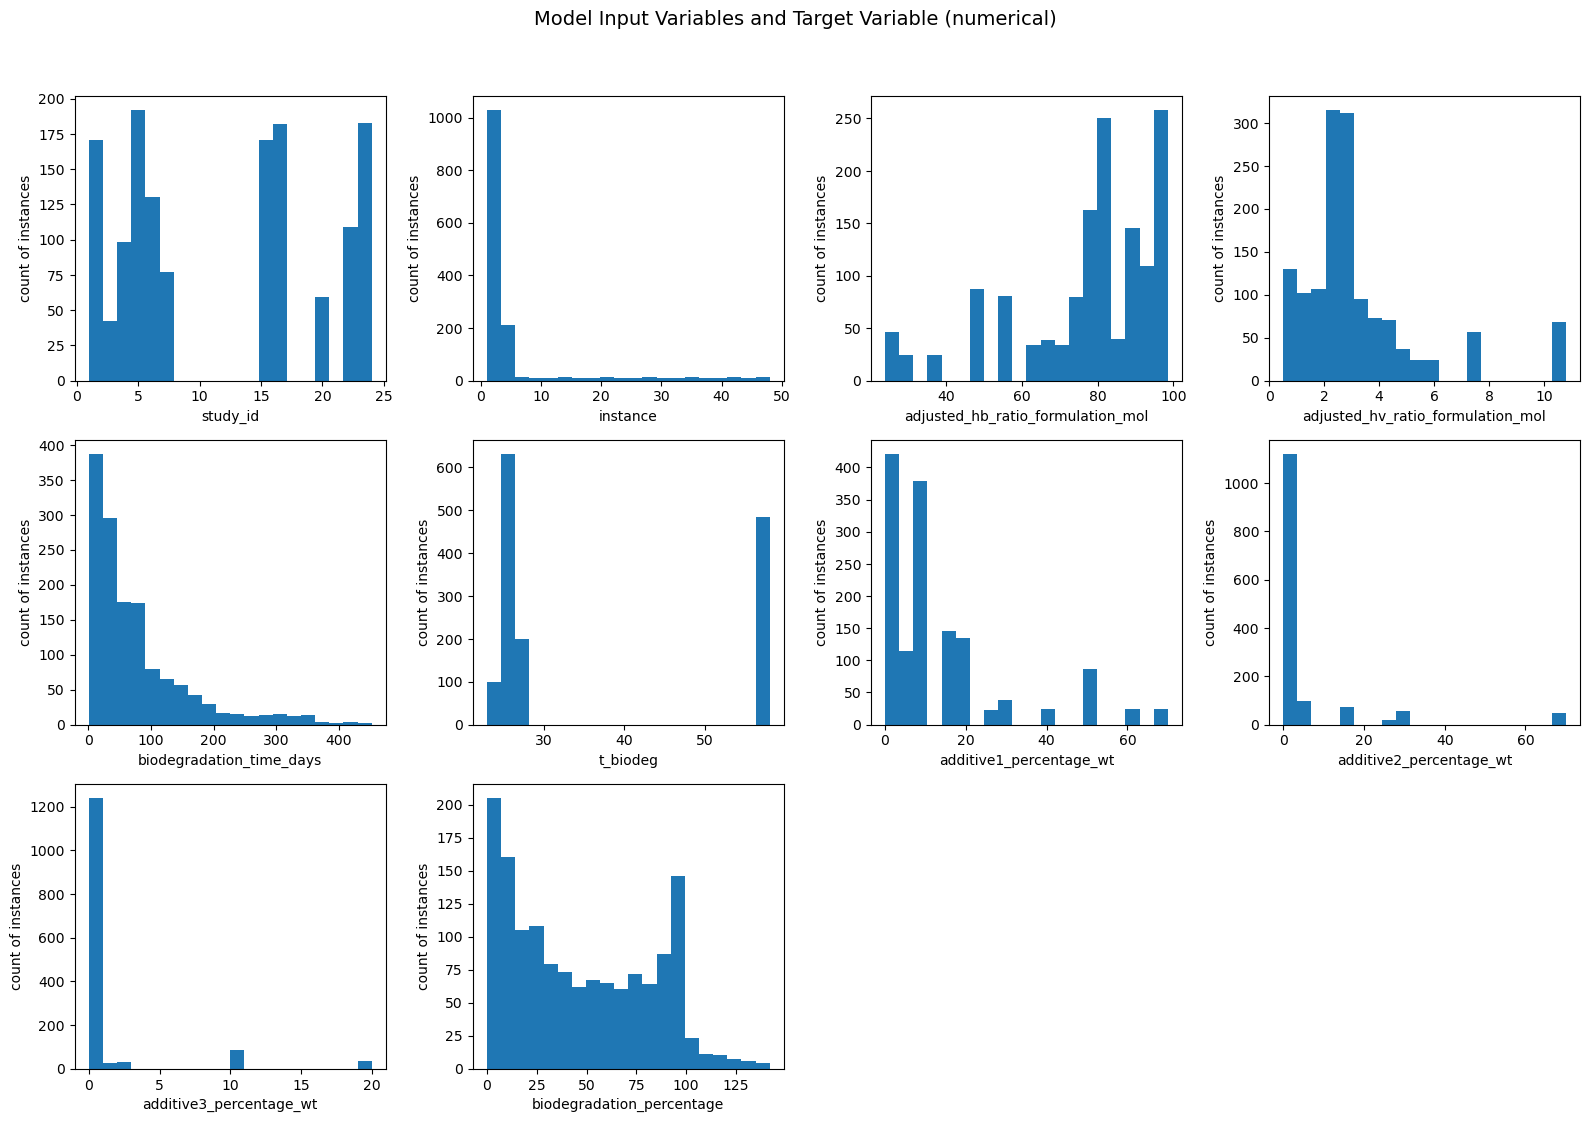

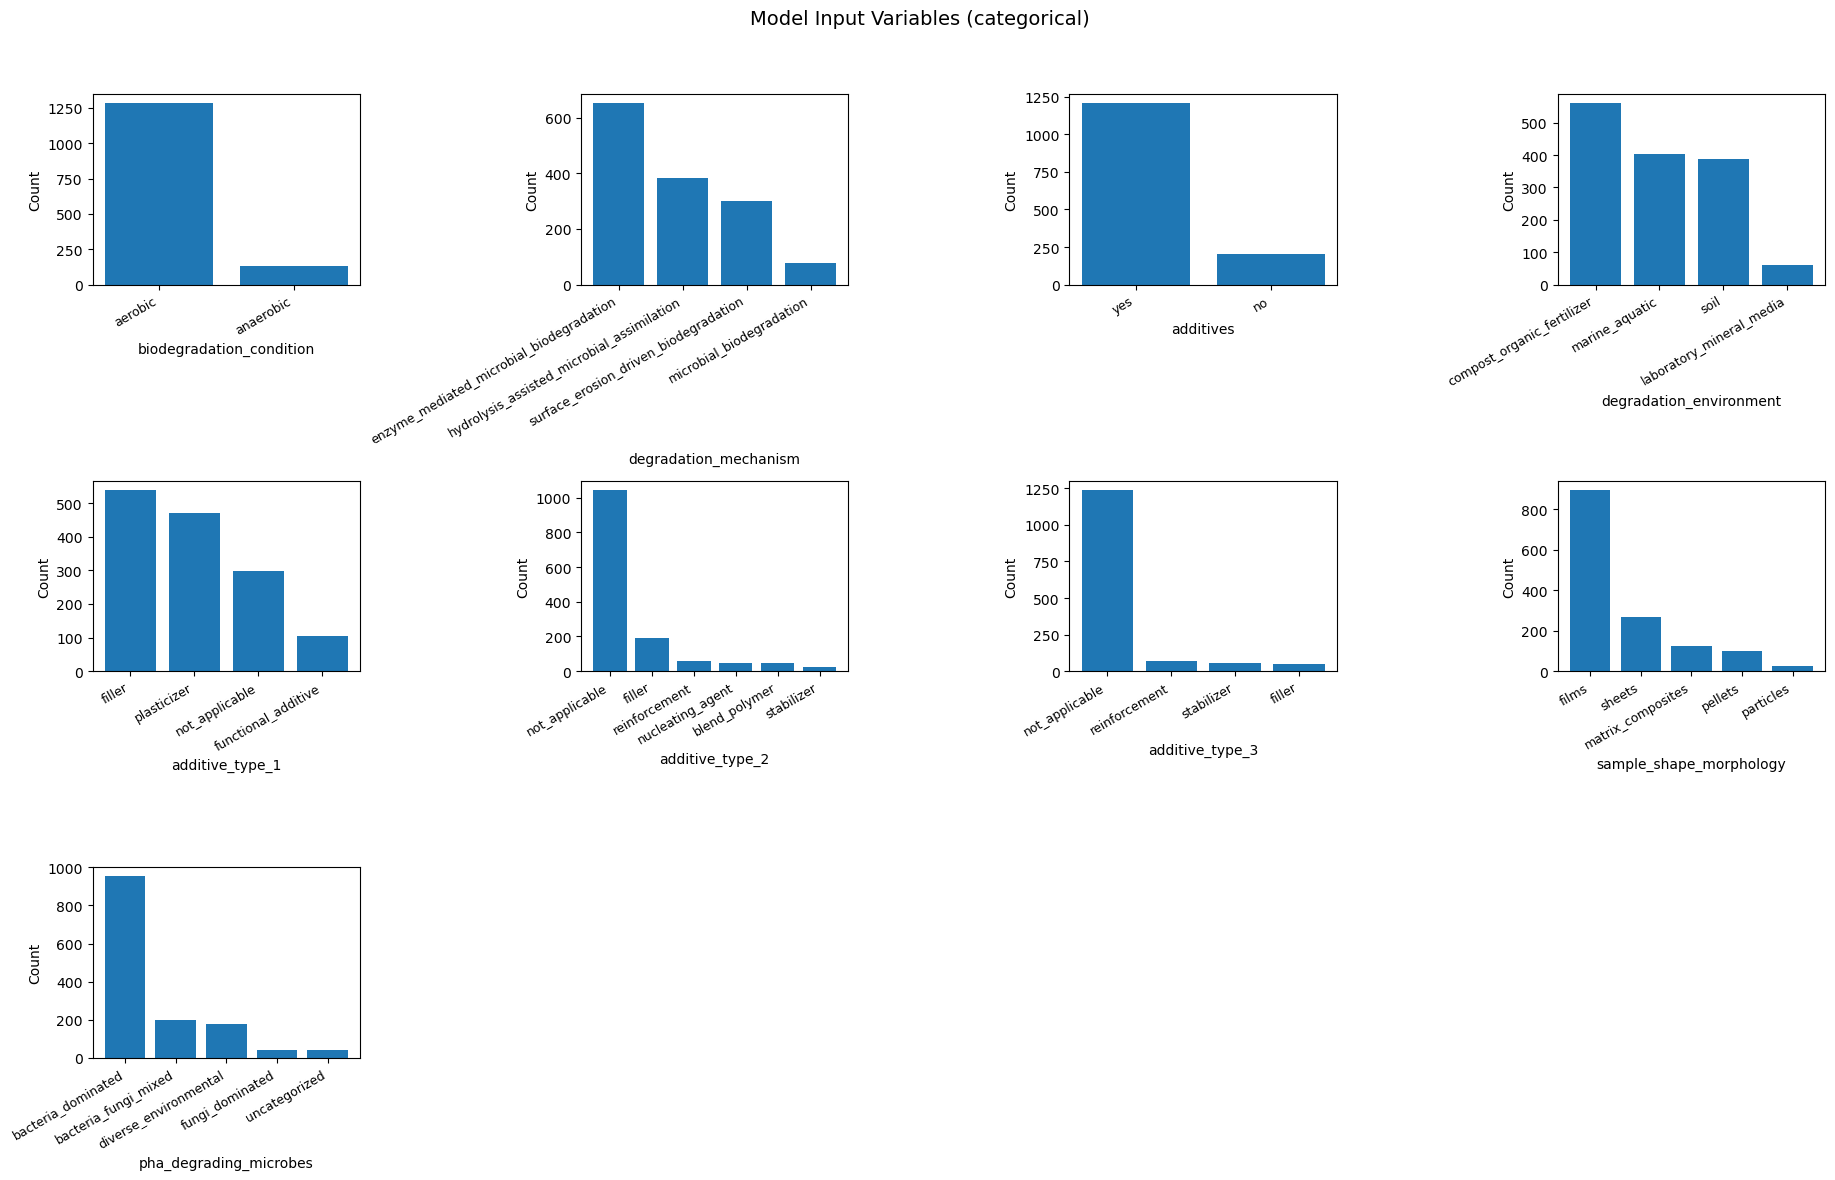

In [44]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numerical_cols,
    categorical_cols,
    title_numeric="Model Input Variables and Target Variable (numerical)",
    title_categorical="Model Input Variables (categorical)",
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,
):
    # ---------- helper to grid-plot ----------
    def _grid_dims(n, max_cols):
        cols = min(max_cols, max(1, n))
        rows = int(math.ceil(n / cols))
        return rows, cols

    # ---------- NUMERICAL ----------
    if len(numerical_cols) > 0:
        n = len(numerical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 3.8*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_numeric, fontsize=14, y=0.98)

        for i, col in enumerate(numerical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            x = df[col].dropna().values
            ax.hist(x, bins=bins)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # ---------- CATEGORICAL ----------
    if len(categorical_cols) > 0:
        n = len(categorical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.0*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_categorical, fontsize=14, y=0.98)

        for i, col in enumerate(categorical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            vc = (df[col].astype(str).replace("nan", np.nan)
                                 .value_counts(dropna=False)
                                 .head(top_k_categories))
            ax.bar(range(len(vc)), vc.values)
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(vc.index.astype(str), rotation=30, ha="right", fontsize=9)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("Count")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

plot_feature_distributions(
    df_final,
    numerical_cols_lst,
    categorical_cols_lst,
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,
)

## Remove features with only one value

In [45]:
constant_cols = df_final.columns[df_final.nunique(dropna=True) <= 1]
print("Removed columns:", list(constant_cols))
df_final = df_final.drop(columns=constant_cols)

Removed columns: []


## Remove rows with biodegradation % > 100%

In [46]:
df_final2 = df_final[df_final["biodegradation_percentage"] <= 100]

df_final2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1364 entries, 0 to 1411
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   study_id                           1364 non-null   int64  
 1   instance                           1364 non-null   int64  
 2   adjusted_hb_ratio_formulation_mol  1364 non-null   float64
 3   adjusted_hv_ratio_formulation_mol  1364 non-null   float64
 4   biodegradation_time_days           1364 non-null   float64
 5   biodegradation_condition           1364 non-null   object 
 6   degradation_mechanism              1364 non-null   object 
 7   additives                          1364 non-null   object 
 8   t_biodeg                           1364 non-null   float64
 9   degradation_environment            1364 non-null   object 
 10  additive_type_1                    1364 non-null   object 
 11  additive1_percentage_wt            1364 non-null   float64
 1

## Reorder columns

In [47]:
first_cols = ['biodegradation_time_days', 'biodegradation_percentage']
df_final2 = df_final2[first_cols + [c for c in df_final2.columns if c not in first_cols]]
df_final2.columns

Index(['biodegradation_time_days', 'biodegradation_percentage', 'study_id',
       'instance', 'adjusted_hb_ratio_formulation_mol',
       'adjusted_hv_ratio_formulation_mol', 'biodegradation_condition',
       'degradation_mechanism', 'additives', 't_biodeg',
       'degradation_environment', 'additive_type_1', 'additive1_percentage_wt',
       'additive_type_2', 'additive2_percentage_wt', 'additive_type_3',
       'additive3_percentage_wt', 'sample_shape_morphology',
       'pha_degrading_microbes'],
      dtype='object')

## Save

In [48]:
df_final2.to_csv('biodegradation_loss_data_LM.csv', index=False)

## Profiling

In [49]:
import sweetviz as sv

exclude_cols = ['study_id', 'instance']
df_subset = df_final2.drop(columns=exclude_cols)

report = sv.analyze(df_subset)
report.show_html("dataset_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report dataset_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
